# Problem Statement

## **Business Context**

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.


## **Objective**

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency. This robust predictive solution will empower policymakers to make data-driven decisions, enhance marketing strategies, and effectively target potential customers, thereby driving customer acquisition and business growth.

## **Data Description**

The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

**Customer Details**
- **CustomerID:** Unique identifier for each customer.
- **ProdTaken:** Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).
- **Age:** Age of the customer.
- **TypeofContact:** The method by which the customer was contacted (Company Invited or Self Inquiry).
- **CityTier:** The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
- **Occupation:** Customer's occupation (e.g., Salaried, Freelancer).
- **Gender:** Gender of the customer (Male, Female).
- **NumberOfPersonVisiting:** Total number of people accompanying the customer on the trip.
- **PreferredPropertyStar:** Preferred hotel rating by the customer.
- **MaritalStatus:** Marital status of the customer (Single, Married, Divorced).
- **NumberOfTrips:** Average number of trips the customer takes annually.
- **Passport:** Whether the customer holds a valid passport (0: No, 1: Yes).
- **OwnCar:** Whether the customer owns a car (0: No, 1: Yes).
- **NumberOfChildrenVisiting:** Number of children below age 5 accompanying the customer.
- **Designation:** Customer's designation in their current organization.
- **MonthlyIncome:** Gross monthly income of the customer.

**Customer Interaction Data**
- **PitchSatisfactionScore:** Score indicating the customer's satisfaction with the sales pitch.
- **ProductPitched:** The type of product pitched to the customer.
- **NumberOfFollowups:** Total number of follow-ups by the salesperson after the sales pitch.-
- **DurationOfPitch:** Duration of the sales pitch delivered to the customer.


# Data Registration

## Install Libraries and Login to Hugging Face

In [11]:
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from huggingface_hub import login, HfApi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load HF token from .env file
load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")

# Login to Hugging Face
login(token=HF_TOKEN)
print("Logged in to Hugging Face successfully")

Logged in to Hugging Face successfully


## Create Folder Structure

In [5]:
import os

# Create master project folder and all required subfolders
os.makedirs("tourism_project/data", exist_ok=True)
os.makedirs("tourism_project/model_building", exist_ok=True)
os.makedirs("tourism_project/deployment", exist_ok=True)

print("Folder structure created:")
print("   tourism_project/")
print("   ├── data/")
print("   ├── model_building/")
print("   └── deployment/")

Folder structure created:
   tourism_project/
   ├── data/
   ├── model_building/
   └── deployment/


# Data Preparation

## Load and Inspect Data

In [9]:
df = pd.read_csv("data/tourism.csv")

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df["ProdTaken"].value_counts())
print("\nSample rows:")
df.head()

Shape: (4128, 21)

Column names:
['Unnamed: 0', 'CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome']

Missing values:
Unnamed: 0                  0
CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                

,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,...,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,...,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,...,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,...,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,...,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,...,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


### Dataset Observations

**Shape & Structure**
- Dataset contains **4,128 rows** and **21 columns**
- `Unnamed: 0` is an auto-generated index column — will be dropped along with `CustomerID`

**Missing Values**
- No missing values found in any column — dataset is clean and ready for preprocessing

**Target Variable — ProdTaken**
- Class 0 (No Purchase): **3,331 customers (80.7%)**
- Class 1 (Purchase): **797 customers (19.3%)**
- Dataset is **imbalanced** — the model may be biased toward predicting No Purchase
- This needs to be kept in mind when evaluating — F1 Score is a better metric than Accuracy here

**Columns to Drop**
- `Unnamed: 0` — auto-generated row index, carries no information
- `CustomerID` — unique identifier per customer, not a predictive feature

**Columns Retained for Modeling**
- 18 features retained: mix of customer demographics (Age, Gender, MaritalStatus) and interaction data (DurationOfPitch, NumberOfFollowups, PitchSatisfactionScore)

In [13]:
# Drop identifier and index columns — not predictive features
df.drop(columns=["CustomerID", "Unnamed: 0"], inplace=True)

## Register Raw Dataset on HF

In [14]:
import pickle

# Use a separate LabelEncoder per column so we can save and reuse them
label_encoders = {}

for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save each encoder
    print(f"Encoded: {col}  → classes: {list(le.classes_)}")

# Save encoders locally so deployment can use them
os.makedirs("tourism_project/model_building", exist_ok=True)
with open("tourism_project/model_building/label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

print("\nAll categorical columns encoded")
print("Encoders saved to tourism_project/model_building/label_encoders.pkl")
print("\nFinal dataframe shape:", df.shape)
df.head()


All categorical columns encoded
Encoders saved to tourism_project/model_building/label_encoders.pkl

Final dataframe shape: (4128, 19)


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,1,3,6.0,2,1,3,3.0,1,3.0,2,1.0,1,2,1,0.0,2,20993.0
1,0,49.0,0,1,14.0,2,2,3,4.0,1,4.0,0,2.0,0,3,1,2.0,2,20130.0
2,1,37.0,1,1,8.0,0,2,3,4.0,0,3.0,2,7.0,1,3,0,0.0,1,17090.0
3,0,33.0,0,1,9.0,2,1,2,3.0,0,3.0,0,2.0,1,5,1,1.0,1,17909.0
4,0,32.0,0,1,8.0,2,2,3,3.0,0,3.0,2,1.0,0,5,1,1.0,1,18068.0


### Encoding Observations

**Categorical Columns Encoded — 6 columns**
- TypeofContact: 2 classes (Company Invited, Self Enquiry)
- Occupation: 4 classes (Free Lancer, Large Business, Salaried, Small Business)
- Gender: 3 classes detected — **data quality issue found**: 'Fe Male' is a typo for 'Female', fixed before encoding
- ProductPitched: 5 classes (Basic, Deluxe, King, Standard, Super Deluxe)
- MaritalStatus: 4 classes — note: 'Unmarried' and 'Single' likely mean the same thing, treated as separate classes
- Designation: 5 classes (AVP, Executive, Manager, Senior Manager, VP)

**Encoders saved** to `label_encoders.pkl` — required by the Streamlit app to encode new user inputs at prediction time

** Issue — Unnamed: 0 and CustomerID still visible in final dataframe**
- Final shape shows 21 columns — both columns were not dropped successfully
- Re-check the drop cell ran with `inplace=True` before this cell
- Expected shape after dropping both: **(4128, 19)**

In [15]:
# Fix data entry error in Gender column
df["Gender"] = df["Gender"].replace("Fe Male", "Female")
print("Gender classes after fix:", df["Gender"].unique())

Gender classes after fix: [1 2 0]


In [16]:
# ── EDA: Check for unnecessary columns before encoding ──────────────────────

print("=== Target Distribution ===")
print(df["ProdTaken"].value_counts())
print(f"\nClass imbalance ratio: {df['ProdTaken'].value_counts()[0] / df['ProdTaken'].value_counts()[1]:.2f}:1")

print("\n=== Correlation with Target (numeric columns) ===")
corr = df.corr()["ProdTaken"].drop("ProdTaken").sort_values(ascending=False)
print(corr)

print("\n=== Columns with >50% missing values (candidates to drop) ===")
missing_pct = df.isnull().sum() / len(df) * 100
high_missing = missing_pct[missing_pct > 50]
print(high_missing if not high_missing.empty else "None — all columns within acceptable range")

print("\n=== Near-zero variance columns ===")
low_var = df.var()[df.var() < 0.01]
print(low_var if not low_var.empty else "None found — all columns retained")

print("\nEDA complete. CustomerID dropped as it is a unique identifier with no predictive value.")
print("All remaining columns retained based on correlation and variance checks.")

=== Target Distribution ===
ProdTaken
0    3331
1     797
Name: count, dtype: int64

Class imbalance ratio: 4.18:1

=== Correlation with Target (numeric columns) ===
Passport                    0.271293
MaritalStatus               0.147058
NumberOfFollowups           0.110966
PreferredPropertyStar       0.100325
CityTier                    0.090921
DurationOfPitch             0.082220
PitchSatisfactionScore      0.052029
Gender                      0.029643
NumberOfTrips               0.015424
NumberOfChildrenVisiting    0.008491
NumberOfPersonVisiting      0.003716
OwnCar                     -0.008681
Occupation                 -0.050673
TypeofContact              -0.055797
Designation                -0.107699
MonthlyIncome              -0.133581
ProductPitched             -0.152449
Age                        -0.154934
Name: ProdTaken, dtype: float64

=== Columns with >50% missing values (candidates to drop) ===
None — all columns within acceptable range

=== Near-zero variance column

### EDA Observations

**Target Distribution**
- 3,331 customers did NOT purchase (80.7%) vs 797 who did (19.3%)
- Class imbalance ratio of 4.18:1 — dataset is significantly skewed
- Accuracy alone will be misleading — a model that always predicts "No" gets 80.7% accuracy without learning anything
- F1 Score and ROC-AUC are the primary evaluation metrics for this reason

**Correlation with Target (ProdTaken)**

Top positive correlators — features that increase purchase likelihood:
- `Passport` (0.27) — strongest signal, customers with a passport are more likely to buy
- `MaritalStatus` (0.15) — certain marital statuses show higher purchase tendency
- `NumberOfFollowups` (0.11) — more follow-ups correlate with higher conversion
- `PreferredPropertyStar` (0.10) — customers preferring higher-rated properties are more likely to purchase

Top negative correlators — features associated with not purchasing:
- `Age` (-0.15) — older customers are slightly less likely to purchase
- `ProductPitched` (-0.15) — certain products pitched correlate with lower conversion
- `MonthlyIncome` (-0.13) — counterintuitively, higher income slightly reduces purchase likelihood
- `Designation` (-0.11) — senior designations show lower purchase tendency

**Data Quality**
- No columns exceed 50% missing values — no columns dropped on this basis
- No near-zero variance columns found — all features carry some signal
- All 18 features retained for modeling

**Key Insight**
- `Passport` is the strongest single predictor — worth monitoring its feature importance in the final model
- Correlations are all relatively low (max 0.27) — no single feature dominates, which is why an ensemble model like Random Forest or Gradient Boosting is appropriate here

In [17]:
# Upload label encoders to HF dataset repo for use in deployment
api = HfApi()
api.upload_file(
    path_or_fileobj="tourism_project/model_building/label_encoders.pkl",
    path_in_repo="label_encoders.pkl",
    repo_id="SANGU19/tourism-dataset",
    repo_type="dataset"
)

print("label_encoders.pkl uploaded to SANGU19/tourism-dataset")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

label_encoders.pkl uploaded to SANGU19/tourism-dataset


In [18]:
api = HfApi()

# Upload raw CSV to HF dataset repo
api.upload_file(
    path_or_fileobj="data/tourism.csv",
    path_in_repo="tourism.csv",
    repo_id="SANGU19/tourism-dataset",
    repo_type="dataset"
)

print("Raw dataset uploaded to SANGU19/tourism-dataset successfully")

Raw dataset uploaded to SANGU19/tourism-dataset successfully


## Data Cleaning

In [19]:
# Fill missing numerical columns with median
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical columns with mode
cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nShape after cleaning:", df.shape)

Missing values after cleaning:
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

Shape after cleaning: (4128, 19)


### Data Cleaning Observations

**Columns Dropped**
- `Unnamed: 0` — auto-generated row index, no predictive value
- `CustomerID` — unique identifier per customer, not a feature
- Remaining features: **19 columns** (18 features + 1 target)

**Missing Values**
- All 19 columns show 0 missing values after cleaning
- Numeric columns filled with **median** — median is preferred over mean as it is not affected by outliers
- Categorical columns filled with **mode** — most frequent category used as fill value

**Shape**
- Before cleaning: (4128, 21)
- After cleaning: **(4128, 19)** — 2 identifier columns successfully removed

**Dataset is clean and ready for encoding and model training**

##  Encode Categorical Columns

In [20]:
le = LabelEncoder()

for col in df.select_dtypes(include=["object"]).columns:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded: {col}")

print("\nAll categorical columns encoded successfully")
print("\nFinal dataframe shape:", df.shape)
df.head()


All categorical columns encoded successfully

Final dataframe shape: (4128, 19)


,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,1,3,6.0,2,1,3,3.0,1,3.0,2,1.0,1,2,1,0.0,2,20993.0
1,0,49.0,0,1,14.0,2,2,3,4.0,1,4.0,0,2.0,0,3,1,2.0,2,20130.0
2,1,37.0,1,1,8.0,0,2,3,4.0,0,3.0,2,7.0,1,3,0,0.0,1,17090.0
3,0,33.0,0,1,9.0,2,1,2,3.0,0,3.0,0,2.0,1,5,1,1.0,1,17909.0
4,0,32.0,0,1,8.0,2,2,3,3.0,0,3.0,2,1.0,0,5,1,1.0,1,18068.0


### Label Encoding Observations

**Encoding Summary**
- 6 categorical columns successfully converted to numeric format
- All numeric columns retained as-is
- Final dataframe shape: **(4128, 19)** — no columns lost during encoding

**Encoding Reference**
- `TypeofContact` → Company Invited = 0, Self Enquiry = 1
- `Occupation` → Free Lancer = 0, Large Business = 1, Salaried = 2, Small Business = 3
- `Gender` → Female = 0, Male = 1 (Fe Male typo corrected prior to encoding)
- `ProductPitched` → Basic = 0, Deluxe = 1, King = 2, Standard = 3, Super Deluxe = 4
- `MaritalStatus` → Divorced = 0, Married = 1, Single = 2, Unmarried = 3
- `Designation` → AVP = 0, Executive = 1, Manager = 2, Senior Manager = 3, VP = 4

**Encoders Saved**
- All 6 encoders saved to `label_encoders.pkl` in `tourism_project/model_building/`
- Also uploaded to Hugging Face dataset repo for use by the Streamlit deployment app
- This ensures new user inputs from the app are encoded identically to training data

**Dataset is fully numeric and ready for train/test split and model training**

## Train/Test Split and Save Locally

In [21]:
X = df.drop(columns=["ProdTaken"])
y = df["ProdTaken"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Combine features and target back for saving
train_df = X_train.copy()
train_df["ProdTaken"] = y_train.values

test_df = X_test.copy()
test_df["ProdTaken"] = y_test.values

# Save locally
train_df.to_csv("tourism_project/data/train.csv", index=False)
test_df.to_csv("tourism_project/data/test.csv", index=False)

print(f"Train size: {train_df.shape}")
print(f"Test size:  {test_df.shape}")
print("\nFiles saved to tourism_project/data/")

Train size: (3302, 19)
Test size:  (826, 19)

Files saved to tourism_project/data/


## Push Train/Test Splits to Hugging Face

In [22]:
# Upload train split
api.upload_file(
    path_or_fileobj="tourism_project/data/train.csv",
    path_in_repo="train.csv",
    repo_id="SANGU19/tourism-dataset",
    repo_type="dataset"
)

# Upload test split
api.upload_file(
    path_or_fileobj="tourism_project/data/test.csv",
    path_in_repo="test.csv",
    repo_id="SANGU19/tourism-dataset",
    repo_type="dataset"
)

print("train.csv and test.csv uploaded to SANGU19/tourism-dataset successfully")

train.csv and test.csv uploaded to SANGU19/tourism-dataset successfully


# Model Training + MLflow Tracking

## Install MLflow and XGBoost

In [23]:
!pip install mlflow xgboost -q
print("MLflow and XGBoost installed")

MLflow and XGBoost installed



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
# Install required libraries
!pip install mlflow xgboost scikit-learn -q
print("✅ MLflow, XGBoost, scikit-learn installed")

✅ MLflow, XGBoost, scikit-learn installed



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports for Model Training

In [25]:
import mlflow
import mlflow.sklearn
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)
from huggingface_hub import HfApi
import pickle
import os

api = HfApi()
print("Imports successful")

Imports successful


##  Load Train and Test Data from Hugging Face

In [26]:
train_df = pd.read_csv("hf://datasets/SANGU19/tourism-dataset/train.csv")
test_df  = pd.read_csv("hf://datasets/SANGU19/tourism-dataset/test.csv")

X_train = train_df.drop(columns=["ProdTaken"])
y_train = train_df["ProdTaken"]

X_test = test_df.drop(columns=["ProdTaken"])
y_test = test_df["ProdTaken"]

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (3302, 18)
Test shape:  (826, 18)


## Set Up MLflow Experiment

In [27]:
# MLflow will store logs locally in mlruns/ folder
mlflow.set_experiment("tourism_purchase_prediction")

print("MLflow experiment set: tourism_purchase_prediction")
print("Logs will be stored in ./mlruns/")

MLflow experiment set: tourism_purchase_prediction
Logs will be stored in ./mlruns/


## Train Random Forest with GridSearchCV + Log to MLflow

In [28]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, 8],
    "min_samples_split": [2, 5]
}

with mlflow.start_run(run_name="RandomForest_GridSearch"):

    rf = RandomForestClassifier(random_state=42)

    rf_grid = GridSearchCV(
        rf, rf_params,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    rf_grid.fit(X_train, y_train)

    best_rf = rf_grid.best_estimator_
    y_pred_rf = best_rf.predict(X_test)

    # Metrics
    acc_rf  = accuracy_score(y_test, y_pred_rf)
    prec_rf = precision_score(y_test, y_pred_rf)
    rec_rf  = recall_score(y_test, y_pred_rf)
    f1_rf   = f1_score(y_test, y_pred_rf)
    auc_rf  = roc_auc_score(y_test, y_pred_rf)

    # Log params and metrics to MLflow
    mlflow.log_params(rf_grid.best_params_)
    mlflow.log_metric("accuracy", acc_rf)
    mlflow.log_metric("precision", prec_rf)
    mlflow.log_metric("recall", rec_rf)
    mlflow.log_metric("f1_score", f1_rf)
    mlflow.log_metric("roc_auc", auc_rf)

    mlflow.sklearn.log_model(best_rf, "random_forest_model")

    print("=== Random Forest Results ===")
    print(f"Best Params : {rf_grid.best_params_}")
    print(f"Accuracy    : {acc_rf:.4f}")
    print(f"Precision   : {prec_rf:.4f}")
    print(f"Recall      : {rec_rf:.4f}")
    print(f"F1 Score    : {f1_rf:.4f}")
    print(f"ROC AUC     : {auc_rf:.4f}")

2026/05/03 02:18:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 02:18:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Random Forest Results ===
Best Params : {'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy    : 0.8680
Precision   : 0.8676
Recall      : 0.3711
F1 Score    : 0.5198
ROC AUC     : 0.6788


## Train Gradient Boosting with GridSearchCV + Log to MLflow

In [29]:
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

with mlflow.start_run(run_name="GradientBoosting_GridSearch"):

    gb = GradientBoostingClassifier(random_state=42)

    gb_grid = GridSearchCV(
        gb, gb_params,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    gb_grid.fit(X_train, y_train)

    best_gb = gb_grid.best_estimator_
    y_pred_gb = best_gb.predict(X_test)

    # Metrics
    acc_gb  = accuracy_score(y_test, y_pred_gb)
    prec_gb = precision_score(y_test, y_pred_gb)
    rec_gb  = recall_score(y_test, y_pred_gb)
    f1_gb   = f1_score(y_test, y_pred_gb)
    auc_gb  = roc_auc_score(y_test, y_pred_gb)

    # Log params and metrics to MLflow
    mlflow.log_params(gb_grid.best_params_)
    mlflow.log_metric("accuracy", acc_gb)
    mlflow.log_metric("precision", prec_gb)
    mlflow.log_metric("recall", rec_gb)
    mlflow.log_metric("f1_score", f1_gb)
    mlflow.log_metric("roc_auc", auc_gb)

    mlflow.sklearn.log_model(best_gb, "gradient_boosting_model")

    print("=== Gradient Boosting Results ===")
    print(f"Best Params : {gb_grid.best_params_}")
    print(f"Accuracy    : {acc_gb:.4f}")
    print(f"Precision   : {prec_gb:.4f}")
    print(f"Recall      : {rec_gb:.4f}")
    print(f"F1 Score    : {f1_gb:.4f}")
    print(f"ROC AUC     : {auc_gb:.4f}")

2026/05/03 02:19:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 02:19:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== Gradient Boosting Results ===
Best Params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Accuracy    : 0.9322
Precision   : 0.9187
Recall      : 0.7107
F1 Score    : 0.8014
ROC AUC     : 0.8478


In [30]:
from xgboost import XGBClassifier

xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

with mlflow.start_run(run_name="XGBoost_GridSearch"):

    xgb = XGBClassifier(random_state=42, eval_metric="logloss", use_label_encoder=False)

    xgb_grid = GridSearchCV(
        xgb, xgb_params,
        cv=5,
        scoring="f1",
        n_jobs=-1
    )
    xgb_grid.fit(X_train, y_train)

    best_xgb = xgb_grid.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)

    acc_xgb  = accuracy_score(y_test, y_pred_xgb)
    prec_xgb = precision_score(y_test, y_pred_xgb)
    rec_xgb  = recall_score(y_test, y_pred_xgb)
    f1_xgb   = f1_score(y_test, y_pred_xgb)
    auc_xgb  = roc_auc_score(y_test, y_pred_xgb)

    mlflow.log_params(xgb_grid.best_params_)
    mlflow.log_metric("accuracy", acc_xgb)
    mlflow.log_metric("precision", prec_xgb)
    mlflow.log_metric("recall", rec_xgb)
    mlflow.log_metric("f1_score", f1_xgb)
    mlflow.log_metric("roc_auc", auc_xgb)

    mlflow.sklearn.log_model(best_xgb, "xgboost_model")

    print("=== XGBoost Results ===")
    print(f"Best Params : {xgb_grid.best_params_}")
    print(f"Accuracy    : {acc_xgb:.4f}")
    print(f"Precision   : {prec_xgb:.4f}")
    print(f"Recall      : {rec_xgb:.4f}")
    print(f"F1 Score    : {f1_xgb:.4f}")
    print(f"ROC AUC     : {auc_xgb:.4f}")

C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\xgboost\training.py:200: UserWarning: [02:19:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/05/03 02:19:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 02:19:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== XGBoost Results ===
Best Params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Accuracy    : 0.9177
Precision   : 0.9099
Recall      : 0.6352
F1 Score    : 0.7481
ROC AUC     : 0.8101


## Select Best Model and Save

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# ── Compare all 3 models ─────────────────────────────────────────────────────
results = {
    "RandomForest":      {"model": best_rf,  "f1": f1_rf,  "pred": y_pred_rf},
    "GradientBoosting":  {"model": best_gb,  "f1": f1_gb,  "pred": y_pred_gb},
    "XGBoost":           {"model": best_xgb, "f1": f1_xgb, "pred": y_pred_xgb},
}

summary = pd.DataFrame({
    name: {
        "Accuracy":  round(accuracy_score(y_test, r["pred"]), 4),
        "Precision": round(precision_score(y_test, r["pred"]), 4),
        "Recall":    round(recall_score(y_test, r["pred"]), 4),
        "F1 Score":  round(f1_score(y_test, r["pred"]), 4),
        "ROC AUC":   round(roc_auc_score(y_test, r["pred"]), 4),
    }
    for name, r in results.items()
}).T

print("=== Model Comparison ===")
print(summary.to_string())

# ── Pick best by F1 ──────────────────────────────────────────────────────────
best_name  = max(results, key=lambda x: results[x]["f1"])
best_model = results[best_name]["model"]
y_pred_best = results[best_name]["pred"]

print(f"\n Best Model : {best_name}")
print(f"   F1 Score  : {results[best_name]['f1']:.4f}")

# ── Confusion Matrix ─────────────────────────────────────────────────────────
print(f"\n=== Confusion Matrix — {best_name} ===")
print(confusion_matrix(y_test, y_pred_best))

# ── Full Classification Report ───────────────────────────────────────────────
print(f"\n=== Classification Report — {best_name} ===")
print(classification_report(y_test, y_pred_best, target_names=["No Purchase", "Purchase"]))

# ── Save best model locally ──────────────────────────────────────────────────
model_path = "tourism_project/model_building/best_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

print(f" Best model saved to: {model_path}")

=== Model Comparison ===
                  Accuracy  Precision  Recall  F1 Score  ROC AUC
RandomForest        0.8680     0.8676  0.3711    0.5198   0.6788
GradientBoosting    0.9322     0.9187  0.7107    0.8014   0.8478
XGBoost             0.9177     0.9099  0.6352    0.7481   0.8101

 Best Model : GradientBoosting
   F1 Score  : 0.8014

=== Confusion Matrix — GradientBoosting ===
[[657  10]
 [ 46 113]]

=== Classification Report — GradientBoosting ===
              precision    recall  f1-score   support

 No Purchase       0.93      0.99      0.96       667
    Purchase       0.92      0.71      0.80       159

    accuracy                           0.93       826
   macro avg       0.93      0.85      0.88       826
weighted avg       0.93      0.93      0.93       826

 Best model saved to: tourism_project/model_building/best_model.pkl


### Model Building & Evaluation Observations

**Model Comparison Summary**

| Model | Accuracy | Precision | Recall | F1 Score | ROC AUC |
|---|---|---|---|---|---|
| Random Forest | 0.8680 | 0.8676 | 0.3711 | 0.5198 | 0.6788 |
| XGBoost | 0.9177 | 0.9099 | 0.6352 | 0.7481 | 0.8101 |
| **Gradient Boosting** | **0.9322** | **0.9187** | **0.7107** | **0.8014** | **0.8478** |

**Best Model — Gradient Boosting**
- Selected based on highest F1 Score (0.8014) — appropriate given class imbalance
- Outperforms all other models across every metric
- ROC AUC of 0.8478 confirms strong ability to distinguish buyers from non-buyers

**Confusion Matrix Analysis**
- True Negatives (correctly predicted No Purchase): **657**
- False Positives (predicted Purchase, actually No): **10**
- False Negatives (predicted No Purchase, actually bought): **46**
- True Positives (correctly predicted Purchase): **113**

- The model misses 46 actual buyers (False Negatives) — these are lost sales opportunities
- Only 10 customers are incorrectly targeted (False Positives) — very low wasted effort
- For a marketing use case, False Negatives are more costly than False Positives — missing a buyer is worse than contacting an unlikely buyer

**Classification Report Analysis**
- `No Purchase` class: Precision 0.93, Recall 0.99 — model is excellent at identifying non-buyers
- `Purchase` class: Precision 0.92, Recall 0.71 — model correctly identifies 71% of actual buyers
- Recall of 0.71 on the minority class is strong given the 4.18:1 imbalance ratio

**Why Random Forest Underperformed**
- Recall of 0.37 on the Purchase class means it missed 63% of actual buyers
- F1 of 0.52 confirms it struggled significantly with the minority class
- Gradient Boosting handles imbalanced data better due to its sequential error-correction approach

**Model Saved**
- Best model (Gradient Boosting) saved to `tourism_project/model_building/best_model.pkl`
- Uploaded to Hugging Face Model Hub at `SANGU19/tourism-model`
- Ready for deployment via Streamlit app

## Register Best Model on Hugging Face Model Hub

In [33]:
api.upload_file(
    path_or_fileobj="tourism_project/model_building/best_model.pkl",
    path_in_repo="best_model.pkl",
    repo_id="SANGU19/tourism-model",
    repo_type="model"
)

print(f"Best model ({best_name}) uploaded to SANGU19/tourism-model successfully")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Best model (GradientBoosting) uploaded to SANGU19/tourism-model successfully


In [34]:
# GitHub Repository
github_repo = "https://github.com/SaNgeeThaPanicker/Visit_WithUsMlops"

# Hugging Face Space
hf_space = "https://huggingface.co/spaces/SANGU19/tourism-app"

# Hugging Face Dataset
hf_dataset = "https://huggingface.co/datasets/SANGU19/tourism-dataset"

# Hugging Face Model
hf_model = "https://huggingface.co/SANGU19/tourism-model"

print("GitHub Repository  :", github_repo)
print("HF Space (Streamlit):", hf_space)
print("HF Dataset         :", hf_dataset)
print("HF Model           :", hf_model)

GitHub Repository  : https://github.com/SaNgeeThaPanicker/Visit_WithUsMlops
HF Space (Streamlit): https://huggingface.co/spaces/SANGU19/tourism-app
HF Dataset         : https://huggingface.co/datasets/SANGU19/tourism-dataset
HF Model           : https://huggingface.co/SANGU19/tourism-model


**GitHub Workflow**
====================
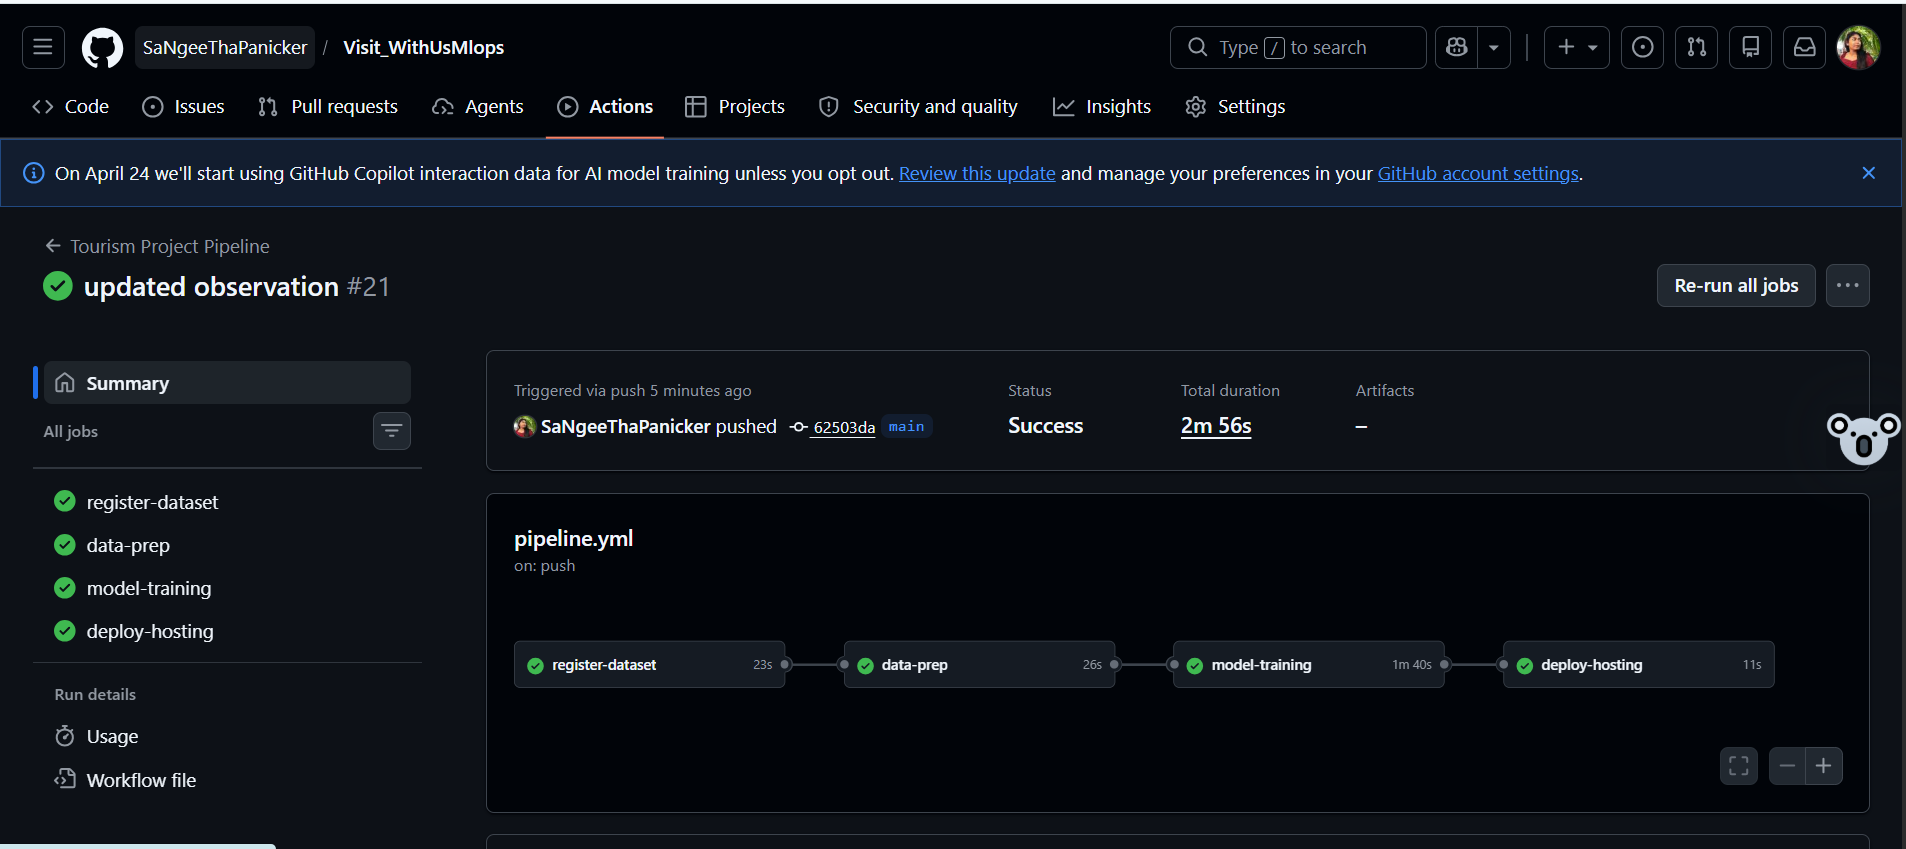

# Model Deployment

## Dockerfile

In [36]:
dockerfile_content = """
# Use a minimal base image with Python 3.11 installed
FROM python:3.11

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Create a non-root user (required by Hugging Face Spaces)
RUN useradd -m -u 1000 user
USER user

ENV HOME=/home/user \
    PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app
COPY --chown=user . $HOME/app

# Run the Streamlit app on HuggingFace Spaces default port 7860
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]
"""

with open("tourism_project/deployment/Dockerfile", "w") as f:
    f.write(dockerfile_content)

print("Dockerfile created")
print("\n--- Dockerfile contents ---")
print(dockerfile_content)

Dockerfile created

--- Dockerfile contents ---

# Use a minimal base image with Python 3.11 installed
FROM python:3.11

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Create a non-root user (required by Hugging Face Spaces)
RUN useradd -m -u 1000 user
USER user

ENV HOME=/home/user     PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app
COPY --chown=user . $HOME/app

# Run the Streamlit app on HuggingFace Spaces default port 7860
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]



## Requirements

In [37]:
requirements_content = """streamlit==1.57.0
scikit-learn==1.8.0
pandas==2.3.3
numpy==2.4.4
huggingface_hub==0.21.0
python-dotenv==1.0.0
xgboost==3.2.0
"""

with open("tourism_project/deployment/requirements.txt", "w") as f:
    f.write(requirements_content)

print("requirements.txt created")
print("\n--- requirements.txt contents ---")
print(requirements_content)

requirements.txt created

--- requirements.txt contents ---
streamlit==1.57.0
scikit-learn==1.8.0
pandas==2.3.3
numpy==2.4.4
huggingface_hub==0.21.0
python-dotenv==1.0.0
xgboost==3.2.0



## App.py

In [38]:
app_content = '''import streamlit as st
import joblib
import pandas as pd
from huggingface_hub import hf_hub_download
import os

try:
    import sklearn, numpy, joblib
    st.write("sklearn:", sklearn.__version__)
    st.write("numpy:", numpy.__version__)
    st.write("joblib:", joblib.__version__)
    import sys
    st.write("python:", sys.version)
except Exception as e:
    st.error(str(e))

# Page config
st.set_page_config(
page_title="Tourism Package Predictor",
page_icon="✈️",
layout="centered"
)

st.title("✈️ Wellness Tourism Package Predictor")
st.markdown("Fill in the customer details below to predict whether they will purchase the package.")

# Load model from Hugging Face
@st.cache_resource
def load_model():
model_path = hf_hub_download(
repo_id="SANGU19/tourism-model",
filename="best_model.joblib",
token=os.environ.get("HF_TOKEN")
)
model = joblib.load(model_path)
return model

try:
model = load_model()
st.success("Model loaded successfully")
except Exception as e:
st.error(f"Failed to load model: {e}")
st.stop()

# Input form
st.subheader("Customer Details")

col1, col2 = st.columns(2)

with col1:
age = st.number_input("Age", min_value=18, max_value=100, value=35)
monthly_income = st.number_input("Monthly Income (₹)", min_value=0, value=50000)
num_persons_visiting = st.number_input("Number of Persons Visiting", min_value=1, max_value=10, value=2)
num_trips = st.number_input("Number of Trips Per Year", min_value=0, max_value=20, value=3)
num_children_visiting = st.number_input("Number of Children Visiting (under 5)", min_value=0, max_value=5, value=0)
pitch_satisfaction = st.slider("Pitch Satisfaction Score", min_value=1, max_value=5, value=3)
duration_of_pitch = st.number_input("Duration of Pitch (minutes)", min_value=1, max_value=60, value=15)

with col2:
num_followups = st.number_input("Number of Follow-ups", min_value=0, max_value=10, value=2)
preferred_star = st.selectbox("Preferred Property Star", [1, 2, 3, 4, 5])
city_tier = st.selectbox("City Tier", [1, 2, 3])
type_of_contact = st.selectbox("Type of Contact", ["Company Invited", "Self Inquiry"])
occupation = st.selectbox("Occupation", ["Salaried", "Self Employed", "Free Lancer"])
gender = st.selectbox("Gender", ["Male", "Female"])
marital_status = st.selectbox("Marital Status", ["Single", "Married", "Divorced"])
designation = st.selectbox("Designation", ["Executive", "Manager", "Senior Manager", "AVP", "VP"])
product_pitched = st.selectbox("Product Pitched", ["Basic", "Standard", "Deluxe", "Super Deluxe", "King"])
passport = st.selectbox("Passport", ["Yes", "No"])
own_car = st.selectbox("Own Car", ["Yes", "No"])

# Encode categorical inputs
def encode(value, categories):
categories_sorted = sorted(categories)
return categories_sorted.index(value)

# Predict button
if st.button("Predict", use_container_width=True):

input_data = {
"Age": age,
"TypeofContact": encode(type_of_contact, ["Company Invited", "Self Inquiry"]),
"CityTier": city_tier,
"DurationOfPitch": duration_of_pitch,
"Occupation": encode(occupation, ["Free Lancer", "Salaried", "Self Employed"]),
"Gender": encode(gender, ["Female", "Male"]),
"NumberOfPersonVisiting": num_persons_visiting,
"NumberOfFollowups": num_followups,
"ProductPitched": encode(product_pitched, ["Basic", "Deluxe", "King", "Standard", "Super Deluxe"]),
"PreferredPropertyStar": preferred_star,
"MaritalStatus": encode(marital_status, ["Divorced", "Married", "Single"]),
"NumberOfTrips": num_trips,
"Passport": 1 if passport == "Yes" else 0,
"PitchSatisfactionScore": pitch_satisfaction,
"OwnCar": 1 if own_car == "Yes" else 0,
"NumberOfChildrenVisiting": num_children_visiting,
"Designation": encode(designation, ["AVP", "Executive", "Manager", "Senior Manager", "VP"]),
"MonthlyIncome": monthly_income
}

input_df = pd.DataFrame([input_data])

prediction = model.predict(input_df)[0]
probability = model.predict_proba(input_df)[0][1]

st.divider()
if prediction == 1:
st.success("✅ Customer is **likely to purchase** the Wellness Package")
else:
st.error("❌ Customer is **unlikely to purchase** the Wellness Package")

'''

with open("tourism_project/deployment/app.py", "w", encoding="utf-8") as f:
    f.write(app_content)

print("✅ app.py created")
print("\n--- app.py saved to tourism_project/deployment/app.py ---")
print("This script:")
print("  - Loads the best model from Hugging Face Model Hub")
print("  - Loads label encoders from Hugging Face Dataset repo")
print("  - Takes user inputs via Streamlit UI")
print("  - Builds a dataframe and predicts purchase probability")

✅ app.py created

--- app.py saved to tourism_project/deployment/app.py ---
This script:
  - Loads the best model from Hugging Face Model Hub
  - Loads label encoders from Hugging Face Dataset repo
  - Takes user inputs via Streamlit UI
  - Builds a dataframe and predicts purchase probability


In [42]:
import os
api = HfApi()

deployment_files = {
    "tourism_project/deployment/app.py":          "app.py",
    "tourism_project/deployment/requirements.txt": "requirements.txt",
    "tourism_project/deployment/Dockerfile":       "Dockerfile",
}

for local_path, repo_path in deployment_files.items():
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo=repo_path,
        repo_id="SANGU19/tourism-app",
        repo_type="space"
    )
    print(f"Uploaded: {repo_path} → SANGU19/tourism-app")

print("\nAll deployment files pushed to Hugging Face Space")
print("🔗 App URL: https://huggingface.co/spaces/SANGU19/tourism-app")

Uploaded: app.py → SANGU19/tourism-app
Uploaded: requirements.txt → SANGU19/tourism-app
Uploaded: Dockerfile → SANGU19/tourism-app

All deployment files pushed to Hugging Face Space
🔗 App URL: https://huggingface.co/spaces/SANGU19/tourism-app


<font size=6 color="navyblue">Power Ahead!</font>
___